# The audit lab — feature behaviour & funnel-stage verification, one roadmap per conversation

This notebook has a single objective: **audit module 2's scraping model against
the conversations that fed it**. It goes back to the initial parquet
(`data/conversations.parquet` — `session_id · message_id · user_id ·
prompt_datetime · question/answer · a_links_source · ai_click · next_10_urls`),
rebuilds the URL events of every conversation *independently* from those raw
link columns, joins each event to the scraper's verdict in
**`fact_scraped_page`** (`outputs/scrape/scraped_pages.parquet`), and asks two
questions:

1. **How are the classifier's features behaving?** Which evidence channels
   (`classification_signals`) actually fire, per category; where the fallback
   chain (`fetch_scope`) landed; how confident the votes were; whether the
   topical-relevance axis and the vendor prior agree with the verdicts.
2. **Are the funnel stages correctly identified?** Every stored
   `funnel_stage` is re-derived from the taxonomy
   (`funnel_stage_for(page_category, page_subtype)` — including the
   cart/checkout → Purchase and order → Post-Purchase bumps), double-checked
   against the URL-only rules (`conveyer.scraping.validate`), and compared
   with the *conversation-side* stage of the turn that surfaced the URL.

The deliverable is **one visual output at the conversation grain**: a journey
**roadmap** — every conversation is a band, every turn and every URL event a
node placed on the funnel lane it was *classified* into, with a red tick to
the lane it *belongs* to whenever the audit disagrees, and the full audit
detail (category, subtype, stage stored vs expected, confidence, signals,
fetch scope, relevance, product↔chat match, dwell) on every node's tooltip.
It connects all outputs of the project — the input parquet, module 1's turn
stages, `fact_scraped_page`, `fact_scraped_product` and module 3's
`funnel_events` — in a single page.

> **Contract:** the lab is a pure *view* of the saved parquets — it scrapes
> nothing and mutates nothing. It assumes the inputs and outputs already
> exist; on a machine where they don't, one offline synthetic pipeline run
> materialises them first (the repo's standard fallback), so the notebook
> executes anywhere.

## 1 · Load the grain and the facts

The grain of the audit is **the conversation**. We load the initial parquet
with `conveyer.ingest.ingest` (same loader as every module — link columns
coerced, timestamps parsed, `session_pos` derived), then the scrape outputs
`fact_scraped_page` + `fact_scraped_product`, and — when present — module 1's
`turn_features` and module 3's `funnel_events` for cross-checks. Provenance is
read from `run_manifest.json` so the roadmap can say out loud what data it
describes.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "conveyer").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_colwidth", 60)

from conveyer.ingest import ingest

INPUT = ROOT / "data/conversations.parquet"
SCRAPE_DIR = ROOT / "outputs/scrape"
LAB_DIR = ROOT / "outputs/audit_lab"
LAB_DIR.mkdir(parents=True, exist_ok=True)

# the standard fallback: when fact_scraped_page is missing, one offline
# synthetic end-to-end run materialises every input and output this lab reads
if not (SCRAPE_DIR / "scraped_pages.parquet").exists():
    from conveyer import (ConversationConfig, JourneyConfig, ScrapeConfig,
                          run_pipeline)
    run_pipeline(
        ConversationConfig(data_path=str(INPUT),
                           out_dir=str(ROOT / "outputs/conversations")),
        ScrapeConfig(clickstream_dir=str(INPUT), out_dir=str(SCRAPE_DIR),
                     model_path=str(SCRAPE_DIR / "page_model.npz"),
                     directory_path=str(ROOT / "data/domain_directory.json"),
                     offline=True),
        JourneyConfig(out_dir=str(ROOT / "outputs/journey")))

conversations, _corpus, ground_truth = ingest(str(INPUT))
pages = pd.read_parquet(SCRAPE_DIR / "scraped_pages.parquet")
products_path = SCRAPE_DIR / "scraped_products.parquet"
products = pd.read_parquet(products_path) if products_path.exists() else None

turnfeat_path = ROOT / "outputs/conversations/turn_features.parquet"
turn_features = pd.read_parquet(turnfeat_path) if turnfeat_path.exists() else None
events_path = ROOT / "outputs/journey/funnel_events.parquet"
saved_events = pd.read_parquet(events_path) if events_path.exists() else None

import re
from conveyer.scraping.readout import source_note_from_manifest
provenance = re.sub(r"<[^>]+>", "", source_note_from_manifest(str(SCRAPE_DIR)) or "")

print(f"conversations : {conversations.attrs.get('source', INPUT)}")
print(f"                {conversations.session_id.nunique()} sessions · "
      f"{len(conversations)} turns")
print(f"fact_scraped_page    : {len(pages)} URLs   ({provenance or 'no manifest'})")
print(f"fact_scraped_product : {0 if products is None else len(products)} products")
print(f"turn_features        : {'-' if turn_features is None else len(turn_features)} rows")
print(f"funnel_events        : {'-' if saved_events is None else len(saved_events)} rows")

conversations : SYNTHETIC (40 sessions, 97 turns)
                40 sessions · 97 turns
fact_scraped_page    : 74 URLs   (Demo corpus, not market data. This run was scraped from the synthetic ground-truth corpus (60 pages, seed 42) — which is why any self-evaluation reads perfect. The page regenerates unchanged from a real run.)
fact_scraped_product : 66 products
turn_features        : 97 rows
funnel_events        : 233 rows


## 2 · Rebuild the event ledger from the raw link columns

The audit must not trust module 3's event table — it *re-derives* the events
straight from the input parquet, with the same shared helpers every module
uses (`link_urls`, `trail_events`): one row per **turn** and one row per **URL
event** (`cited` = `a_links_source`, `ai_click`, `trail_visit` =
`next_10_urls` with 1-based position and dwell), sequenced in journey order
within each session. Conversation-side funnel stages come fresh from
`conveyer.funnel` — the keyword classifier per turn plus the HMM-smoothed
`journey_stage` — so the page-side labels can be compared against what the
*conversation* was doing at that moment.

In [2]:
from conveyer.funnel import STAGES, add_stage, fit_journey_hmm
from conveyer.ingest import link_urls, trail_events

turns = add_stage(conversations)                      # keyword stage per turn
_hmm, turns = fit_journey_hmm(turns)                  # + HMM-smoothed stage
turns = turns.rename(columns={"funnel_stage": "conv_stage_kw",
                              "journey_stage": "conv_stage_hmm"})

ledger_rows = []
for sid, g in turns.sort_values(["session_id", "session_pos"]).groupby("session_id"):
    seq = 0
    for _, t in g.iterrows():
        base = {"session_id": sid, "user_id": t.get("user_id", ""),
                "message_id": t["message_id"], "session_pos": int(t["session_pos"]),
                "conv_stage_kw": t["conv_stage_kw"], "conv_stage_hmm": t["conv_stage_hmm"]}
        ledger_rows.append({**base, "seq": (seq := seq + 1), "kind": "turn",
                            "event_type": "turn", "url": "",
                            "position": None, "dwell_seconds": None,
                            "question": str(t["question"])[:180]})
        clicked = set(link_urls(t.get("ai_click")))
        for url in link_urls(t.get("a_links_source")):
            ledger_rows.append({**base, "seq": (seq := seq + 1), "kind": "event",
                                "event_type": "cited", "url": url,
                                "position": None, "dwell_seconds": None, "question": ""})
        for url in clicked:
            ledger_rows.append({**base, "seq": (seq := seq + 1), "kind": "event",
                                "event_type": "ai_click", "url": url,
                                "position": None, "dwell_seconds": None, "question": ""})
        for ev in trail_events(t.get("next_10_urls")):
            ledger_rows.append({**base, "seq": (seq := seq + 1), "kind": "event",
                                "event_type": "trail_visit", "url": ev["url"],
                                "position": ev["position"],
                                "dwell_seconds": ev["dwell_seconds"], "question": ""})

ledger = pd.DataFrame(ledger_rows)
events = ledger[ledger.kind == "event"].copy()
print(f"{ledger.session_id.nunique()} sessions → {len(ledger)} ledger rows "
      f"({(ledger.kind == 'turn').sum()} turns + {len(events)} URL events)")
print(events.event_type.value_counts().to_string())

40 sessions → 330 ledger rows (97 turns + 233 URL events)
event_type
trail_visit    134
cited           80
ai_click        19


## 3 · Connect the conversations to `fact_scraped_page`

Every event URL joins to the scraped fact table on `url`. What doesn't join is
itself a finding (`page_coverage="url_only"`): those events fall back to the
URL-only multimodal classifier — exactly what module 3 does — so stage
coverage is always 100%, but the roadmap will show them hollow, because their
label is not backed by a scraped page. Products roll up per URL
(`fact_scraped_product`) so each node can say what was found on the page and
whether it coincides with what the agent recommended.

In [3]:
from conveyer.scraping import ScrapeConfig, classify_url

PAGE_COLS = ["url", "page_category", "page_subtype", "funnel_stage",
             "seller_type", "page_category_confidence", "classifier_method",
             "classification_signals", "fetch_status", "fetch_scope",
             "skincare_relevance", "is_study_relevant", "chat_match_strength",
             "chat_match_score", "prior_page_type", "primary_brand"]
page_facts = pages[[c for c in PAGE_COLS if c in pages.columns]].copy()
page_facts["classification_signals"] = page_facts["classification_signals"].apply(
    lambda v: list(v) if v is not None and not isinstance(v, float) else [])

audit = events.merge(page_facts, on="url", how="left")
audit["page_coverage"] = np.where(audit["page_category"].notna(), "pages", "url_only")

# URL-only fallback (same as module 3) — coverage becomes 100%, flagged
# hollow. The learned model is off, matching validate.py's contract: audit
# verdicts must be deterministic and identical on every machine, and the lab
# must never write a model file as a side effect.
_cfg = ScrapeConfig(directory_path=str(ROOT / "data/domain_directory.json"),
                    use_learned_model=False)
_cache = {}
for url in audit.loc[audit.page_coverage == "url_only", "url"].unique():
    c = classify_url(url, _cfg)
    _cache[url] = {"page_category": c.page_category, "page_subtype": c.page_subtype,
                   "funnel_stage": c.funnel_stage, "seller_type": c.seller_type,
                   "page_category_confidence": c.confidence, "classifier_method": c.method,
                   "classification_signals": list(c.signals),
                   "skincare_relevance": c.skincare_relevance,
                   "is_study_relevant": c.is_study_relevant,
                   "primary_brand": c.primary_brand}
for i in audit.index[audit.page_coverage == "url_only"]:
    for k, v in _cache[audit.at[i, "url"]].items():
        audit.at[i, k] = v

# fact_scraped_product roll-up per URL: what the page sells, and the best
# match back to the chat mention
if products is not None and len(products):
    tier = {"exact": 3, "strong": 2, "likely": 1, "none": 0}
    prod_roll = products.groupby("url").agg(
        n_products=("product_id", "size"),
        any_coincides=("coincides", "any"),
        best_match=("match_strength",
                    lambda s: max(s, key=lambda v: tier.get(str(v), 0), default="none")),
        product_names=("name", lambda s: "; ".join(list(s.astype(str))[:3])),
    ).reset_index()
    audit = audit.merge(prod_roll, on="url", how="left")
else:
    audit[["n_products", "any_coincides", "best_match", "product_names"]] =         [0, False, "none", ""]
audit["n_products"] = audit["n_products"].fillna(0).astype(int)
audit["any_coincides"] = audit["any_coincides"].fillna(False).astype(bool)
audit["best_match"] = audit["best_match"].fillna("none")
audit["product_names"] = audit["product_names"].fillna("")

cov = audit.page_coverage.value_counts(normalize=True).mul(100).round(1)
print(f"join coverage: {cov.to_dict()}  (of {len(audit)} events, "
      f"{audit.url.nunique()} distinct URLs)")
assert audit.funnel_stage.notna().all(), "every event must carry a funnel stage"

join coverage: {'pages': 100.0}  (of 233 events, 74 distinct URLs)


## 4 · Feature-behaviour lab

How the classifier's features behaved *on the pages this study actually
touched*. Four views:

* **fallback chain & method** — where the content that earned each label came
  from (`fetch_scope`: page → stripped → base → directory → none) and which
  classifier path ran (`classifier_method`);
* **evidence channels per category** — which of the independent voters
  (`classification_signals`: url / domain / markup / content / prior /
  platform / model / directory …) fired for each `page_category`. A category
  leaning on a single channel is fragile; `url_override` / `url_validated` /
  `reclassified` marks are repairs worth reading;
* **confidence** — the vote's decisiveness per category, against the 0.55
  threshold below which the optional LLM refinement would engage;
* **topical relevance** — the `skincare_relevance` score against the
  `is_study_relevant` verdict (topic-neutral journey infrastructure is
  legitimately relevant at score 0 — carts prove no topic).

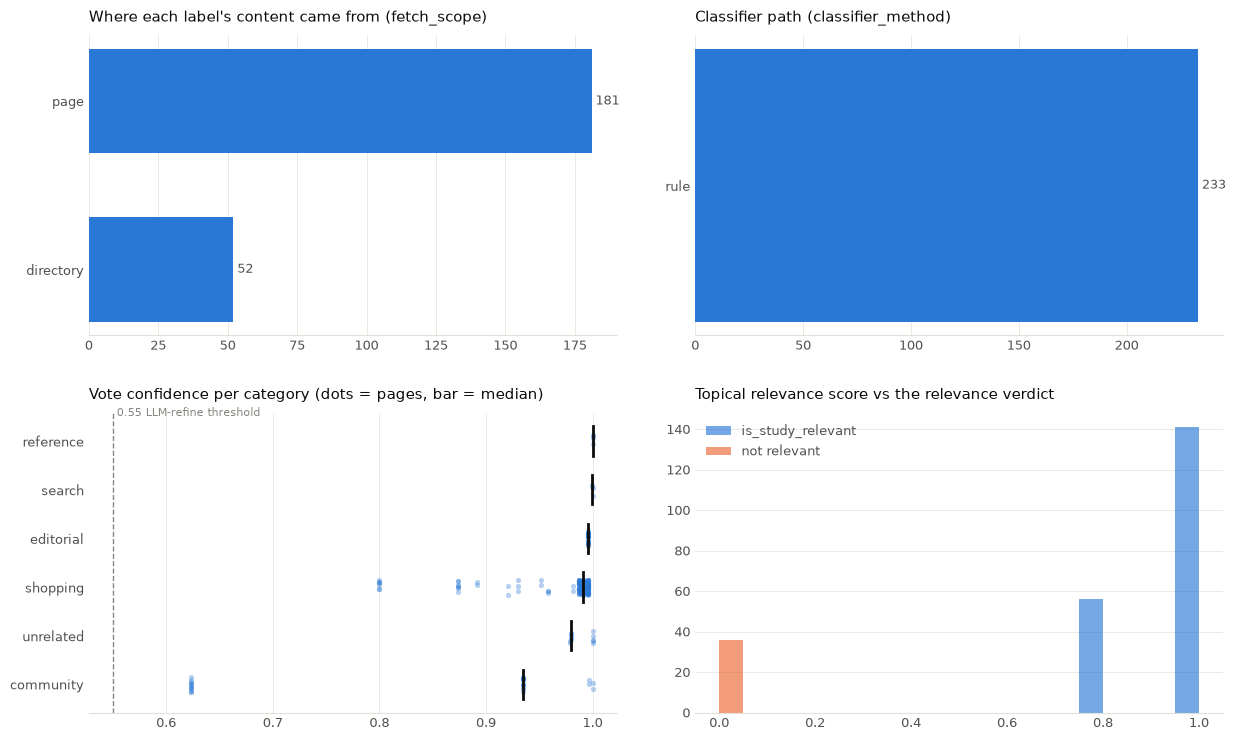

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt

INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
S1, S2 = "#2a78d6", "#eb6834"                       # categorical slots 1–2
SEQ = mpl.colors.LinearSegmentedColormap.from_list(
    "seq_blue", ["#f6f9fe", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
STAGE_ORDER = STAGES + ["Irrelevant"]
STAGE_INDEXES = {s: i for i, s in enumerate(STAGE_ORDER)}
STAGE_COLORS = {"Awareness": "#2a78d6", "Discovery": "#eb6834",
                "Evaluation": "#1baf7a", "Intent": "#eda100",
                "Purchase": "#e87ba4", "Post-Purchase": "#008300",
                "Irrelevant": "#c3c2b7"}            # slots 1–6 + neutral

def style(ax, grid_axis="x"):
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=0)
    ax.grid(axis=grid_axis, color=GRID, lw=.6, alpha=.8)
    ax.set_axisbelow(True)

def hbars(ax, series, title, color=S1):
    series = series.sort_values()
    ax.barh(series.index.astype(str), series.values, color=color, height=.62)
    for i, v in enumerate(series.values):
        ax.text(v, i, f" {v:,}", va="center", ha="left", fontsize=9, color=INK2)
    ax.set_title(title, loc="left", fontsize=11, color=INK, pad=10)
    style(ax)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.5), facecolor="white")
hbars(axes[0, 0], audit.fetch_scope.fillna("—").value_counts(),
      "Where each label's content came from (fetch_scope)")
hbars(axes[0, 1], audit.classifier_method.fillna("—").value_counts(),
      "Classifier path (classifier_method)")

catmed = audit.groupby("page_category")["page_category_confidence"].median()
order = catmed.sort_values().index.tolist()
rng = np.random.default_rng(7)
ax = axes[1, 0]
for i, cat in enumerate(order):
    vals = audit.loc[audit.page_category == cat, "page_category_confidence"].dropna()
    ax.scatter(vals, i + rng.uniform(-.16, .16, len(vals)), s=14, color=S1,
               alpha=.35, linewidths=0)
    ax.plot([catmed[cat]] * 2, [i - .3, i + .3], color=INK, lw=2)
ax.axvline(.55, color=MUTED, lw=1, ls="--")
ax.text(.55, len(order) - .3, " 0.55 LLM-refine threshold", fontsize=8,
        color=MUTED, va="top")
ax.set_yticks(range(len(order)), order)
ax.set_title("Vote confidence per category (dots = pages, bar = median)",
             loc="left", fontsize=11, color=INK, pad=10)
style(ax)

ax = axes[1, 1]
bins = np.linspace(0, 1, 21)
for flag, color, label in [(True, S1, "is_study_relevant"),
                           (False, S2, "not relevant")]:
    ax.hist(audit.loc[audit.is_study_relevant == flag, "skincare_relevance"],
            bins=bins, color=color, alpha=.65, label=label)
ax.legend(frameon=False, fontsize=9, labelcolor=INK2)
ax.set_title("Topical relevance score vs the relevance verdict",
             loc="left", fontsize=11, color=INK, pad=10)
style(ax, grid_axis="y")
fig.tight_layout(w_pad=3, h_pad=2.5)
plt.show()

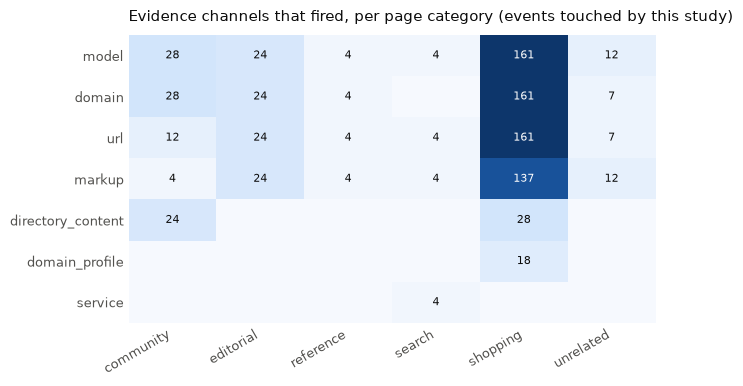

events below the 0.55 confidence bar : 0.0%
events not backed by a scraped page  : 0.0%
events with a vendor prior present   : 0 (0% of those blended it in)


In [5]:
sig = audit[["page_category", "classification_signals"]].explode("classification_signals")
sig = sig.dropna(subset=["classification_signals"]).reset_index(drop=True)
mat = pd.crosstab(sig.classification_signals, sig.page_category)
mat = mat.loc[mat.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(1.1 + .95 * len(mat.columns), .8 + .42 * len(mat)),
                       facecolor="white")
im = ax.imshow(mat.values, cmap=SEQ, aspect="auto")
ax.set_xticks(range(len(mat.columns)), mat.columns, rotation=30, ha="right")
ax.set_yticks(range(len(mat)), mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        if v:
            ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=8,
                    color="white" if v > mat.values.max() * .55 else INK)
ax.set_title("Evidence channels that fired, per page category "
             "(events touched by this study)", loc="left", fontsize=11,
             color=INK, pad=10)
ax.tick_params(colors=INK2, labelsize=9, length=0)
for s in ax.spines.values():
    s.set_visible(False)
plt.show()

low_conf = (audit.page_category_confidence < .55).mean()
url_only = (audit.page_coverage == "url_only").mean()
prior = audit[audit.prior_page_type.fillna("").ne("")]
print(f"events below the 0.55 confidence bar : {low_conf:.1%}")
print(f"events not backed by a scraped page  : {url_only:.1%}")
print(f"events with a vendor prior present   : {len(prior)} "
      f"({0 if not len(prior) else (prior.classifier_method.str.contains('prior')).mean():.0%} "
      f"of those blended it in)")

## 5 · Funnel-stage audit — is every stage correctly identified?

Three independent checks, strongest first:

1. **Taxonomy re-derivation.** The stored `funnel_stage` must equal
   `funnel_stage_for(page_category, page_subtype)` — including the bumps
   (cart/checkout → Purchase, order → Post-Purchase, wishlist stays Intent).
   Any mismatch is a stage that does not belong where it was classified.
2. **The URL-rule double-check** (`conveyer.scraping.validate`): stored labels
   re-audited against the URL-only rules — a `shopping` row whose URL carries
   a decisive cart token but whose subtype disagrees moves the conversion
   proxy, so it is flagged even when the category looks fine.
3. **Conversation coherence.** The stage the *conversation* was in (keyword +
   HMM per turn) vs the stage of the pages that turn surfaced — the two sides
   were inferred by different modules from different evidence, so systematic
   disagreement (e.g. Intent-stage turns surfacing Awareness pages) is either
   a classifier miss or a real behavioural insight; the crosstab says which
   pairs to inspect.

In [6]:
from conveyer.scraping.taxonomy import funnel_stage_for
from conveyer.scraping.validate import validation_report

# 1 — taxonomy re-derivation on every event
audit["expected_stage"] = [funnel_stage_for(c, s) for c, s in
                           zip(audit.page_category, audit.page_subtype)]
audit["flag_taxonomy"] = audit.funnel_stage != audit.expected_stage

# 2 — URL-rule double-check, on the pages this study actually touched
touched = pages[pages.url.isin(audit.url)].reset_index(drop=True)
url_report = validation_report(touched, _cfg)
flagged_urls = set(url_report.url) if len(url_report) else set()
audit["flag_url_rules"] = audit.url.isin(flagged_urls)

audit["flag_low_confidence"] = audit.page_category_confidence < .55
audit["flag_repaired"] = audit.classification_signals.apply(
    lambda s: any(m in (s or []) for m in ("url_validated", "reclassified", "human")))
audit["flagged"] = audit.flag_taxonomy | audit.flag_url_rules

n_tax, n_url = int(audit.flag_taxonomy.sum()), int(audit.flag_url_rules.sum())
print(f"1 · taxonomy re-derivation : {n_tax} mismatching events "
      f"({'PASS — every stored stage re-derives' if n_tax == 0 else 'REVIEW below'})")
if n_tax:
    display(audit.loc[audit.flag_taxonomy,
                      ["session_id", "url", "page_category", "page_subtype",
                       "funnel_stage", "expected_stage"]].drop_duplicates("url"))
print(f"2 · URL-rule double-check  : {len(url_report)} suspect pages "
      f"({'PASS — labels consistent with their URLs' if not len(url_report) else 'REVIEW below'})")
if len(url_report):
    display(url_report)

# the purchase-bump subtypes, explicitly — these move the conversion proxy
bump = audit[audit.page_subtype.isin(["cart", "checkout", "order", "wishlist"])]
print("\npurchase-bump subtypes (must be Purchase / Purchase / Post-Purchase / Intent):")
print(bump.groupby(["page_subtype", "funnel_stage"]).size()
      .rename("events").reset_index().to_string(index=False))

1 · taxonomy re-derivation : 0 mismatching events (PASS — every stored stage re-derives)
2 · URL-rule double-check  : 0 suspect pages (PASS — labels consistent with their URLs)

purchase-bump subtypes (must be Purchase / Purchase / Post-Purchase / Intent):
page_subtype funnel_stage  events
        cart     Purchase      14
    checkout     Purchase      14


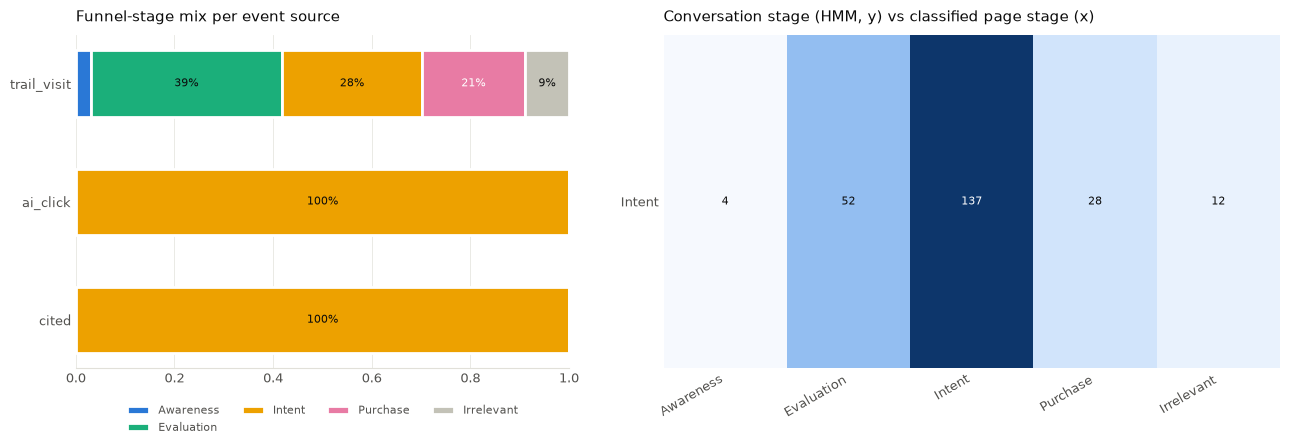

3 · saved funnel_events cross-check: 233/233 events matched, stage agreement 100.0%


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), facecolor="white",
                               gridspec_kw={"width_ratios": [1, 1.25]})

# stage mix per event source — does what the agent cites differ from where
# users actually browse?
mix = (audit.groupby(["event_type", "funnel_stage"]).size().unstack(fill_value=0)
       .reindex(columns=[s for s in STAGE_ORDER if s in
                         set(audit.funnel_stage)], fill_value=0)
       .reindex(["cited", "ai_click", "trail_visit"]).fillna(0))
share = mix.div(mix.sum(axis=1).replace(0, 1), axis=0).fillna(0)
left = np.zeros(len(share))
for stage in share.columns:
    ax1.barh(share.index, share[stage], left=left, color=STAGE_COLORS[stage],
             height=.56, label=stage, edgecolor="white", linewidth=2)
    for i, (frac, n) in enumerate(zip(share[stage], mix[stage])):
        if frac > .07:
            ax1.text(left[i] + frac / 2, i, f"{frac:.0%}", ha="center",
                     va="center", fontsize=8,
                     color="white" if stage not in ("Intent", "Irrelevant",
                                                    "Evaluation") else INK)
    left += share[stage].values
ax1.set_xlim(0, 1)
ax1.set_title("Funnel-stage mix per event source", loc="left", fontsize=11,
              color=INK, pad=10)
ax1.legend(frameon=False, fontsize=8, labelcolor=INK2, ncols=4,
           loc="upper center", bbox_to_anchor=(.5, -.08))
style(ax1)

# conversation stage at the turn vs the stage of the pages it surfaced
ct = pd.crosstab(audit.conv_stage_hmm, audit.funnel_stage)
ct = ct.reindex(index=[s for s in STAGES if s in ct.index],
                columns=[s for s in STAGE_ORDER if s in ct.columns])
im = ax2.imshow(ct.values, cmap=SEQ, aspect="auto")
ax2.set_xticks(range(len(ct.columns)), ct.columns, rotation=30, ha="right")
ax2.set_yticks(range(len(ct.index)), ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        if v:
            ax2.text(j, i, f"{v:,}", ha="center", va="center", fontsize=8,
                     color="white" if v > ct.values.max() * .55 else INK)
ax2.set_title("Conversation stage (HMM, y) vs classified page stage (x)",
              loc="left", fontsize=11, color=INK, pad=10)
ax2.tick_params(colors=INK2, labelsize=9, length=0)
for s in ax2.spines.values():
    s.set_visible(False)
fig.tight_layout(w_pad=3)
plt.show()

# 3 — cross-check against module 3's saved funnel_events, when present
if saved_events is not None:
    key = ["session_id", "message_id", "url", "event_type"]
    x = audit.merge(saved_events[key + ["funnel_stage"]].rename(
        columns={"funnel_stage": "saved_stage"}).drop_duplicates(key),
        on=key, how="left")
    m = x.saved_stage.notna()
    agree = (x.loc[m, "funnel_stage"] == x.loc[m, "saved_stage"]).mean()
    print(f"3 · saved funnel_events cross-check: {m.sum()}/{len(x)} events matched, "
          f"stage agreement {agree:.1%}")
    if m.any() and agree < 1:
        display(x.loc[m & (x.funnel_stage != x.saved_stage),
                      ["url", "event_type", "funnel_stage", "saved_stage"]]
                .drop_duplicates().head(10))

## 6 · The roadmap — every conversation, one band; every URL, one node

The single visual the lab exists for. Reading guide:

* **one horizontal band per conversation** (the grain), lanes = the
  `dim_ai_funnel` stages top-to-bottom (Awareness → Post-Purchase, Irrelevant
  at the bottom in gray). The thin gray road connects turns and events in
  journey order, so the line literally descends as the session moves toward
  purchase;
* **node shape = what happened** — ◆ a conversation turn (on its HMM stage
  lane) · ▪ a link the agent cited · ▲ a click straight from the answer ·
  ● a browsing-trail visit. Node color repeats the lane's stage (the lane
  position is the encoding; color is reinforcement — identity is never color
  alone);
* **hollow nodes** were never scraped — their label comes from the URL-only
  fallback (`page_coverage="url_only"`), not from `fact_scraped_page`;
* **audit marks in red**: a red ring = the stored stage does not re-derive
  from its own category/subtype (check 1); a dashed red ring = the URL-rule
  double-check disagrees (check 2). A red tick drops to the lane the page
  *belongs* to, so "classified as vs belongs to" is one glance;
* **hover any node** for the full audit record: URL, event, category ·
  subtype · seller, stage stored/expected, confidence, method, evidence
  signals, fetch status/scope, relevance, products found and the chat-match
  tier, dwell.

The page is self-contained HTML (inline SVG, no JS, light/dark aware), also
written to `outputs/audit_lab/journey_roadmap.html` for sharing.

In [8]:
import html as _html

FLAG = "#e34948"                                       # status: serious
NODE_R, LANE_H, BAND_PAD, INFO_W, LBL_W, ROAD_W = 5, 17, 26, 216, 86, 1050
BAND_H = LANE_H * len(STAGE_ORDER) + BAND_PAD
MAX_SESSIONS = None            # cap for huge corpora; None = every conversation

_esc = lambda s: _html.escape(str(s), quote=True)
lane_y = {s: i * LANE_H + LANE_H / 2 for i, s in enumerate(STAGE_ORDER)}
gt_by_sid = ({str(r.session_id): str(r.gt_archetype)
              for r in ground_truth.itertuples()} if ground_truth is not None else {})

def _node_tip(r):
    lines = [f"{r.event_type.upper()} · {r.url}",
             f"classified: {r.page_category} · {r.page_subtype} · seller {r.seller_type}",
             f"stage stored {r.funnel_stage} | expected {r.expected_stage}"
             + ("  ⚠ MISMATCH" if r.flag_taxonomy else ""),
             f"confidence {r.page_category_confidence:.2f} · method {r.classifier_method}",
             f"signals: {', '.join(r.classification_signals or []) or '—'}",
             f"fetch {r.fetch_status or '—'} · scope {r.fetch_scope or '—'} · "
             f"coverage {r.page_coverage}",
             f"relevance {r.skincare_relevance:.2f} → "
             f"{'study-relevant' if r.is_study_relevant else 'not relevant'}"]
    if r.n_products:
        lines.append(f"{r.n_products} product(s): {r.product_names} · "
                     f"chat match {r.best_match}"
                     + (" · COINCIDES" if r.any_coincides else ""))
    if r.prior_page_type:
        lines.append(f"vendor prior: {r.prior_page_type}")
    if r.dwell_seconds is not None and not pd.isna(r.dwell_seconds):
        lines.append(f"dwell {r.dwell_seconds:.0f}s · trail position {int(r.position)}")
    if r.flag_url_rules:
        lines.append("⚠ URL-rule double-check disagrees (see §5)")
    return "&#10;".join(_esc(x) for x in lines)

def _shape(kind, x, y, fill, stroke, extra=""):
    if kind == "turn":
        return (f'<path d="M{x},{y - 6.5} L{x + 6.5},{y} L{x},{y + 6.5} '
                f'L{x - 6.5},{y} Z" fill="{fill}" stroke="{stroke}" '
                f'stroke-width="1.4"{extra}/>')
    if kind == "cited":
        return (f'<rect x="{x - 4.6}" y="{y - 4.6}" width="9.2" height="9.2" '
                f'rx="1.6" fill="{fill}" stroke="{stroke}" stroke-width="1.4"{extra}/>')
    if kind == "ai_click":
        return (f'<path d="M{x},{y - 6} L{x + 5.7},{y + 4.4} L{x - 5.7},{y + 4.4} Z" '
                f'fill="{fill}" stroke="{stroke}" stroke-width="1.4"{extra}/>')
    return (f'<circle cx="{x}" cy="{y}" r="{NODE_R}" fill="{fill}" '
            f'stroke="{stroke}" stroke-width="1.4"{extra}/>')

sessions = list(ledger.session_id.unique())
if MAX_SESSIONS and len(sessions) > MAX_SESSIONS:
    print(f"[roadmap] capping at {MAX_SESSIONS} of {len(sessions)} sessions — "
          f"raise MAX_SESSIONS to draw them all")
    sessions = sessions[:MAX_SESSIONS]

total_w = INFO_W + LBL_W + ROAD_W + 30
total_h = len(sessions) * BAND_H + 8
svg = [f'<svg viewBox="0 0 {total_w} {total_h}" role="img" '
       f'style="width:100%;height:auto;display:block">']
audit_key = audit.set_index(["session_id", "seq"])

for si, sid in enumerate(sessions):
    band = ledger[ledger.session_id == sid].sort_values("seq")
    y0 = si * BAND_H
    ev = audit[audit.session_id == sid]
    depth = [s for s in STAGES if s in set(ev.funnel_stage)]
    max_stage = depth[-1] if depth else "—"
    n_flag = int(ev.flagged.sum())
    if si % 2:
        svg.append(f'<rect x="0" y="{y0}" width="{total_w}" height="{BAND_H}" '
                   f'class="zebra"/>')
    info = [f'<text x="14" y="{y0 + 22}" class="sid">{_esc(sid)}</text>',
            f'<text x="14" y="{y0 + 38}" class="meta">{_esc(band.user_id.iloc[0])}'
            f' · {int((band.kind == "turn").sum())} turns · {len(ev)} events</text>',
            f'<text x="14" y="{y0 + 54}" class="meta">deepest: {max_stage}'
            + (f' · <tspan class="flagtx">{n_flag} flagged</tspan>' if n_flag
               else ' · clean') + '</text>']
    if gt_by_sid:
        info.append(f'<text x="14" y="{y0 + 70}" class="meta">truth: '
                    f'{_esc(gt_by_sid.get(str(sid), "?"))}</text>')
    svg += info
    for stage, ly in lane_y.items():
        yy = y0 + BAND_PAD / 2 + ly
        svg.append(f'<line x1="{INFO_W + LBL_W}" y1="{yy}" '
                   f'x2="{INFO_W + LBL_W + ROAD_W}" y2="{yy}" class="lane"/>')
        svg.append(f'<text x="{INFO_W + LBL_W - 6}" y="{yy}" class="lanelbl" '
                   f'text-anchor="end" dominant-baseline="central">{stage}</text>')
    n = len(band)
    xs = (ROAD_W - 32) / max(n - 1, 1)
    pts, marks = [], []
    for k, (_, r) in enumerate(band.iterrows()):
        x = INFO_W + LBL_W + 16 + (k * xs if n > 1 else (ROAD_W - 32) / 2)
        if r.kind == "turn":
            y = y0 + BAND_PAD / 2 + lane_y[r.conv_stage_hmm]
            tip = (f"TURN {r.session_pos} · {_esc(r.question)}&#10;"
                   f"keyword stage {r.conv_stage_kw} · HMM stage {r.conv_stage_hmm}")
            marks.append(f'<g class="nd"><title>{tip}</title>'
                         + _shape("turn", x, y, f'var(--st-{STAGE_INDEXES[r.conv_stage_hmm]})',
                                  "var(--ink2)") + "</g>")
        else:
            a = audit_key.loc[(sid, r.seq)]
            y = y0 + BAND_PAD / 2 + lane_y[a.funnel_stage]
            hollow = a.page_coverage == "url_only"
            color = f'var(--st-{STAGE_INDEXES[a.funnel_stage]})'
            fill = "var(--surface)" if hollow else color
            ring = ""
            if a.flag_taxonomy or a.flag_url_rules:
                dash = ' stroke-dasharray="2.5,2"' if (a.flag_url_rules
                                                       and not a.flag_taxonomy) else ""
                ring = (f'<circle cx="{x}" cy="{y}" r="{NODE_R + 3.6}" fill="none" '
                        f'stroke="var(--flag)" stroke-width="1.6"{dash}/>')
                ey = y0 + BAND_PAD / 2 + lane_y[a.expected_stage]
                if abs(ey - y) > 1:
                    ring += (f'<line x1="{x}" y1="{y}" x2="{x}" y2="{ey}" '
                             f'stroke="var(--flag)" stroke-width="1.2" '
                             f'stroke-dasharray="3,2.5"/>'
                             f'<line x1="{x - 4}" y1="{ey}" x2="{x + 4}" y2="{ey}" '
                             f'stroke="var(--flag)" stroke-width="2"/>')
            marks.append(f'<g class="nd"><title>{_node_tip(a)}</title>{ring}'
                         + _shape(a.event_type, x, y, fill, color) + "</g>")
        pts.append(f"{x},{y}")
    svg.append(f'<polyline points="{" ".join(pts)}" class="road"/>')
    svg += marks
svg.append("</svg>")

n_nodes = sum(1 for s in svg if 'class="nd"' in s)
assert n_nodes == len(ledger[ledger.session_id.isin(sessions)]),     "every ledger row must appear as a node"
print(f"roadmap: {len(sessions)} conversations · {n_nodes} nodes "
      f"({int(audit[audit.session_id.isin(sessions)].flagged.sum())} flagged)")

roadmap: 40 conversations · 330 nodes (0 flagged)


In [9]:
# assemble the page: tokens define light; dark redefines tokens only
STAGE_LIGHT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
               "#008300", "#c3c2b7"]
STAGE_DARK = ["#3987e5", "#d95926", "#199e70", "#c98500", "#d55181",
              "#008300", "#52514e"]
_light = "".join(f"--st-{i}:{c};" for i, c in enumerate(STAGE_LIGHT))
_dark = "".join(f"--st-{i}:{c};" for i, c in enumerate(STAGE_DARK))

legend_stages = "".join(
    f'<span class="chip"><i style="background:var(--st-{i})"></i>{s}</span>'
    for i, s in enumerate(STAGE_ORDER))
legend_shapes = ('<span class="chip">◆ turn</span><span class="chip">▪ cited</span>'
                 '<span class="chip">▲ ai click</span><span class="chip">● trail visit</span>'
                 '<span class="chip">○ hollow = url-only (never scraped)</span>')
legend_flags = ('<span class="chip flagtx">⭘ red ring = stage ≠ taxonomy</span>'
                '<span class="chip flagtx">⌇ dashed = URL-rule disagrees</span>'
                '<span class="chip flagtx">┬ tick = the lane it belongs to</span>')

src = conversations.attrs.get("source", str(INPUT))
prov_txt = f" · {_esc(provenance)}" if provenance else ""
roadmap_html = f'''<title>conveyer — journey roadmap audit</title>
<style>
:root {{ --page:#f9f9f7; --surface:#fcfcfb; --ink:#0b0b0b; --ink2:#52514e;
  --muted:#898781; --grid:#e1e0d9; --flag:#e34948; --chip:#f0efec; {_light} }}
@media (prefers-color-scheme: dark) {{ :root:not([data-theme="light"]) {{
  --page:#0d0d0d; --surface:#1a1a19; --ink:#ffffff; --ink2:#c3c2b7;
  --muted:#898781; --grid:#2c2c2a; --flag:#e66767; --chip:#262624; {_dark} }} }}
:root[data-theme="dark"] {{ --page:#0d0d0d; --surface:#1a1a19; --ink:#ffffff;
  --ink2:#c3c2b7; --muted:#898781; --grid:#2c2c2a; --flag:#e66767;
  --chip:#262624; {_dark} }}
body {{ background:var(--page); color:var(--ink); margin:0;
  font:13px/1.45 ui-sans-serif,system-ui,sans-serif }}
.wrap {{ max-width:1420px; margin:0 auto; padding:20px }}
h1 {{ font-size:19px; margin:0 0 4px }}
.sub {{ color:var(--ink2); margin:0 0 12px }}
.legend {{ display:flex; flex-wrap:wrap; gap:6px; margin:0 0 14px }}
.chip {{ background:var(--chip); border-radius:999px; padding:3px 10px;
  font-size:11px; color:var(--ink2); display:inline-flex; align-items:center; gap:6px }}
.chip i {{ width:10px; height:10px; border-radius:3px; display:inline-block }}
.flagtx {{ color:var(--flag) }}
.card {{ background:var(--surface); border:1px solid var(--grid);
  border-radius:10px; padding:10px; overflow-x:auto }}
.zebra {{ fill:var(--chip); opacity:.45 }}
.lane {{ stroke:var(--grid); stroke-width:1 }}
.lanelbl {{ font-size:8.5px; fill:var(--muted) }}
.road {{ fill:none; stroke:var(--muted); stroke-width:1.1; opacity:.55 }}
.sid {{ font-size:12.5px; font-weight:600; fill:var(--ink) }}
.meta {{ font-size:10.5px; fill:var(--ink2) }}
.nd:hover path, .nd:hover circle, .nd:hover rect {{ stroke-width:2.4 }}
</style>
<div class="wrap">
<h1>Journey roadmap — the conversations vs <code>fact_scraped_page</code></h1>
<p class="sub">{_esc(src)} · {len(sessions)} conversations · {n_nodes} nodes{prov_txt} ·
coverage {(audit.page_coverage == "pages").mean():.0%} scraped ·
{int(audit.flagged.sum())} events flagged by the stage audit</p>
<div class="legend">{legend_stages}</div>
<div class="legend">{legend_shapes}</div>
<div class="legend">{legend_flags}</div>
<div class="card">{"".join(svg)}</div>
</div>'''

out_path = LAB_DIR / "journey_roadmap.html"
out_path.write_text(roadmap_html, encoding="utf-8")
print(f"wrote {out_path} ({len(roadmap_html):,} bytes)")

from conveyer.scraping.readout import iframe
iframe(roadmap_html, height=940)

wrote /home/user/conveyer/outputs/audit_lab/journey_roadmap.html (226,655 bytes)


## 7 · Persist the audit + verdict

The event-grain audit table (every URL event with its stored vs expected
stage, flags, evidence and product match) and the conversation-grain summary
are written next to the roadmap, so the findings are queryable after the
notebook closes.

In [10]:
export = audit.copy()
export["classification_signals"] = export.classification_signals.apply(
    lambda s: "|".join(s or []))
export.drop(columns=["question"]).to_parquet(LAB_DIR / "audit_events.parquet",
                                             index=False)

summary = (audit.groupby("session_id")
           .agg(n_events=("url", "size"),
                n_urls=("url", "nunique"),
                pct_scraped=("page_coverage", lambda s: (s == "pages").mean()),
                pct_relevant=("is_study_relevant", "mean"),
                n_flagged=("flagged", "sum"),
                n_taxonomy_flags=("flag_taxonomy", "sum"),
                n_url_rule_flags=("flag_url_rules", "sum"),
                deepest_stage=("funnel_stage",
                               lambda s: max((x for x in s if x in STAGES),
                                             key=STAGES.index, default="—")))
           .reset_index())
summary.to_parquet(LAB_DIR / "audit_sessions.parquet", index=False)
display(summary.head(10))

verdict = "PASS" if not audit.flagged.any() else "REVIEW"
print(f"[audit verdict] {verdict} — {int(audit.flagged.sum())} of {len(audit)} "
      f"events flagged · taxonomy {int(audit.flag_taxonomy.sum())} · "
      f"URL rules {int(audit.flag_url_rules.sum())}")
print(f"[export] {LAB_DIR}/: journey_roadmap.html, audit_events.parquet, "
      f"audit_sessions.parquet")

,session_id,n_events,n_urls,pct_scraped,pct_relevant,n_flagged,n_taxonomy_flags,n_url_rule_flags,deepest_stage
0,s0000,5,5,1.0,0.4,0,0,0,Intent
1,s0001,7,5,1.0,1.0,0,0,0,Purchase
2,s0002,5,5,1.0,1.0,0,0,0,Intent
3,s0003,6,3,1.0,1.0,0,0,0,Intent
4,s0004,7,5,1.0,1.0,0,0,0,Purchase
5,s0005,5,5,1.0,1.0,0,0,0,Intent
6,s0006,6,3,1.0,1.0,0,0,0,Intent
7,s0007,7,5,1.0,1.0,0,0,0,Purchase
8,s0008,5,5,1.0,0.4,0,0,0,Intent
9,s0009,5,5,1.0,0.4,0,0,0,Intent


[audit verdict] PASS — 0 of 233 events flagged · taxonomy 0 · URL rules 0
[export] /home/user/conveyer/outputs/audit_lab/: journey_roadmap.html, audit_events.parquet, audit_sessions.parquet


## 8 · Acting on findings

* a **red-ringed node** (stored stage ≠ taxonomy) or a §5 URL-rule suspect →
  repair in place, audited: `python -m conveyer.scraping.validate
  outputs/scrape/scraped_pages.parquet --apply` (adds `+url_validated`);
* a **relevance miss** (e.g. an on-topic PDP marked `unrelated`) → the
  content-aware rescue: `… validate --reclassify --apply` (re-reads the cached
  HTML, never re-fetches);
* a **wrong label the rules keep making** → the human loop
  ([notebook 03](03_relabel_workflow.ipynb)): `relabel export` ranks suspects
  (the flags exported here feed the same queue), corrections apply at
  confidence 1.0 and retrain the learned channel;
* **hollow nodes** concentrated on one domain → that domain never got
  scraped; add it to `data/domain_directory.json` or re-run the scrape
  online for those URLs.

Re-run this notebook after any of the above — the roadmap is a pure view of
the parquets, so the rings disappear exactly when the data is fixed.